# Girsanov Theorem: Change of Measure in Stochastic Calculus

## What is it?
The **Girsanov Theorem** tells us how to change the probability measure under which a stochastic process evolves, specifically to **remove or add drift** to a Brownian motion while preserving its "Brownian" structure.

## The Setup
- Start with a probability space $(\Omega, \mathcal{F}, P)$ and a standard Brownian motion $W_t$ under $P$.
- We want a new measure $Q$ such that the process has different drift properties.

## The Theorem (Constant $\theta$ Version)
If $W_t$ is a Brownian motion under $P$, define the **Radon-Nikodym derivative**:

$$Z_t = \exp\left(-\theta W_t - \frac{1}{2}\theta^2 t\right)$$

Then under the measure $Q$ defined by $\frac{dQ}{dP}\big|_{\mathcal{F}_t} = Z_t$, the process:

$$W_t^Q = W_t + \theta t$$

is a **standard Brownian motion under $Q$**.

## Key Intuition
- Under $P$: $W_t$ has **zero drift**.
- Under $Q$: the same path $W_t$ is viewed as $W_t^Q - \theta t$, i.e., a Brownian motion **minus** a deterministic drift.
- Equivalently: $dW_t^Q = dW_t + \theta\,dt$, so a process $dX_t = \mu\,dt + \sigma\,dW_t$ becomes driftless $dX_t = \sigma\,dW_t^Q$ if we choose $\theta = \mu/\sigma$.

## Novikov Condition
For $Z_t$ to be a true martingale (and $Q$ to be equivalent to $P$), we need:
$$\mathbb{E}_P\left[\exp\left(\frac{1}{2}\int_0^T \theta_s^2\,ds\right)\right] < \infty$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# ============ PARAMETERS ============
T = 1.0          # Time horizon
N = 1000         # Number of time steps
dt = T / N       # Time step size
t = np.linspace(0, T, N + 1)
n_paths = 10     # Number of sample paths to plot
n_samples = 50000  # Number of paths for density estimation
theta = 0.8      # Constant drift adjustment parameter

# ============ SIMULATION ============
# Brownian motion increments under P
dW = np.random.normal(0, np.sqrt(dt), size=(n_paths, N))
# Cumulative sum to get W_t paths
W = np.zeros((n_paths, N + 1))
W[:, 1:] = np.cumsum(dW, axis=1)

# Under Q: W^Q_t = W_t + theta * t is a Brownian motion under Q
W_Q = W + theta * t

# Radon-Nikodym derivative process (Doléans-Dade exponential)
Z = np.exp(-theta * W - 0.5 * theta**2 * t)

# For density plots: simulate many paths
dW_many = np.random.normal(0, np.sqrt(dt), size=(n_samples, N))
W_many = np.zeros((n_samples, N + 1))
W_many[:, 1:] = np.cumsum(dW_many, axis=1)
Z_many = np.exp(-theta * W_many[:, -1] - 0.5 * theta**2 * T)

print("Setup complete. E[Z_T] under P ≈", np.mean(Z_many))


Setup complete. E[Z_T] under P ≈ 1.001201746225048


## Visualization 1: Brownian Motion under P vs. Q

The same underlying paths are interpreted differently under the two measures:
- **Under P**: $W_t$ is a standard BM (zero drift, variance $t$).
- **Under Q**: $W_t^Q = W_t + \theta t$ is a standard BM.

Visually, the Q-paths are the P-paths shifted upward by $\theta t$. Under $Q$, what looks like "upward drift" in $W_t$ is just the natural variation of $W_t^Q$.


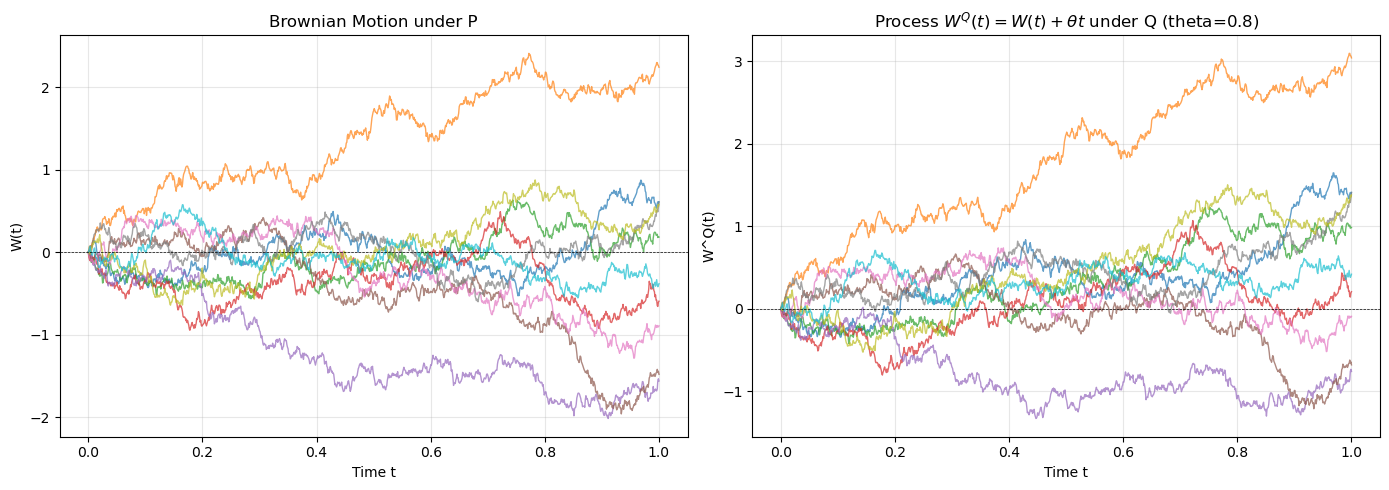

In [2]:
# ============ PLOT 1: P-BM vs Q-BM ============
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Under measure P
ax = axes[0]
for i in range(n_paths):
    ax.plot(t, W[i], alpha=0.7, linewidth=1)
ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_title('Brownian Motion under P', fontsize=12)
ax.set_xlabel('Time t')
ax.set_ylabel('W(t)')
ax.grid(True, alpha=0.3)

# Right: Under measure Q (W^Q is BM under Q)
ax = axes[1]
for i in range(n_paths):
    ax.plot(t, W_Q[i], alpha=0.7, linewidth=1)
ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
title = r'Process $W^Q(t) = W(t) + \theta t$ under Q' + ' (theta={})'.format(theta)
ax.set_title(title, fontsize=12)
ax.set_xlabel('Time t')
ax.set_ylabel('W^Q(t)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Visualization 2: The Radon-Nikodym Derivative $Z_t$

$Z_t$ is the **likelihood ratio** between $Q$ and $P$ up to time $t$. It tells us how much to reweight events when switching measures.

Properties:
- $Z_0 = 1$
- $Z_t > 0$ always (measures are equivalent)
- $Z_t$ is a **martingale** under $P$: $\mathbb{E}_P[Z_t] = 1$
- $Z_t$ tends to decrease when $W_t$ is large and positive (since $\theta > 0$), because $Q$ "expects" less upward drift than what $P$ observes.

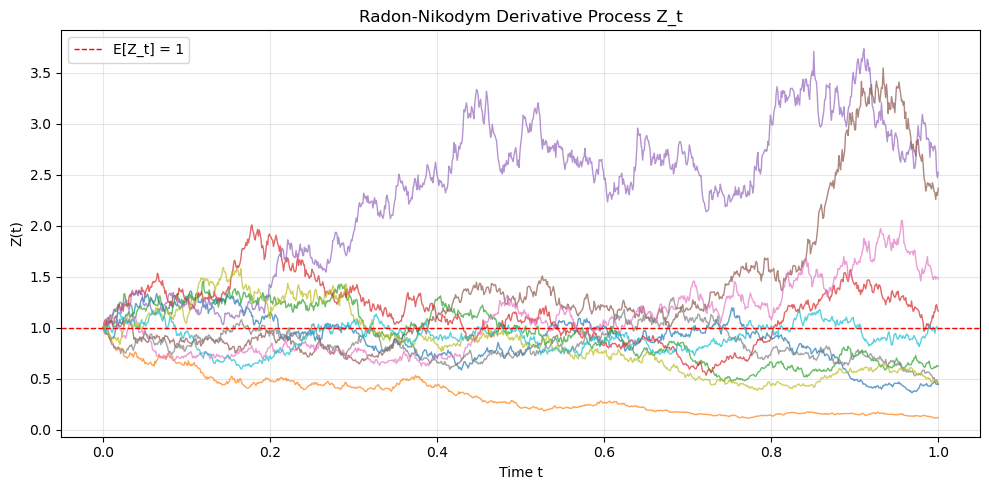

In [3]:
# ============ PLOT 2: Radon-Nikodym Derivative ============
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(n_paths):
    ax.plot(t, Z[i], alpha=0.7, linewidth=1)
ax.axhline(1, color='red', linestyle='--', linewidth=1, label='E[Z_t] = 1')
ax.set_title('Radon-Nikodym Derivative Process Z_t', fontsize=12)
ax.set_xlabel('Time t')
ax.set_ylabel('Z(t)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Visualization 3: Density Transformation at Terminal Time

Under $P$: $W_T \sim \mathcal{N}(0, T)$.

Under $Q$: the density of $W_T$ is reweighted by $Z_T$. Algebraically:
$$f_Q(x) = f_P(x) \cdot \exp(-\theta x - \tfrac{1}{2}\theta^2 T) \propto \exp\left(-\frac{(x + \theta T)^2}{2T}\right)$$

So under $Q$: $W_T \sim \mathcal{N}(-\theta T, T)$.

The histogram on the right is computed by **weighting** the $P$-samples with $Z_T$ — no new simulation under $Q$ is needed!


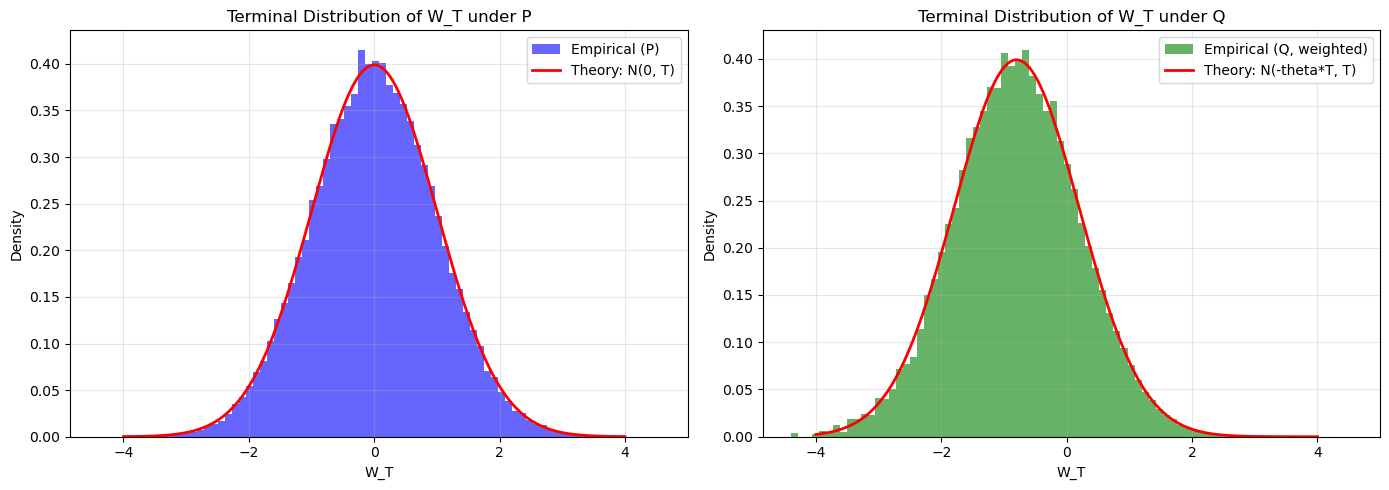

In [4]:
# ============ PLOT 3: Terminal Density Transformation ============
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Under P: W_T ~ N(0, T)
ax = axes[0]
ax.hist(W_many[:, -1], bins=80, density=True, alpha=0.6, color='blue', 
        label='Empirical (P)')
x_range = np.linspace(-4, 4, 200)
ax.plot(x_range, stats.norm.pdf(x_range, 0, np.sqrt(T)), 'r-', linewidth=2,
        label='Theory: N(0, T)')
ax.set_title('Terminal Distribution of W_T under P', fontsize=12)
ax.set_xlabel('W_T')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)

# Under Q: weighted by Z_T
ax = axes[1]
ax.hist(W_many[:, -1], bins=80, density=True, alpha=0.6, color='green',
        weights=Z_many, label='Empirical (Q, weighted)')
# Theoretical Q-density of W_T: N(-theta*T, T)
ax.plot(x_range, stats.norm.pdf(x_range, -theta*T, np.sqrt(T)), 'r-', linewidth=2,
        label='Theory: N(-theta*T, T)')
ax.set_title('Terminal Distribution of W_T under Q', fontsize=12)
ax.set_xlabel('W_T')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Visualization 4: Application — Removing Drift

Consider a process with drift:
$$dX_t = \mu\,dt + \sigma\,dW_t \quad \text{(under P)}$$

Choose $\theta = \mu/\sigma$. Then:
$$dX_t = \sigma\,(dW_t + \theta\,dt) = \sigma\,dW_t^Q$$

So under $Q$, $X_t = \sigma W_t^Q$ is a **martingale** (driftless)!

The left panel shows $X_t$ under $P$ (with visible upward drift).  
The right panel shows the **exact same paths** rewritten as $\sigma W_t^Q$ — now interpreted as driftless Brownian motion under $Q$.


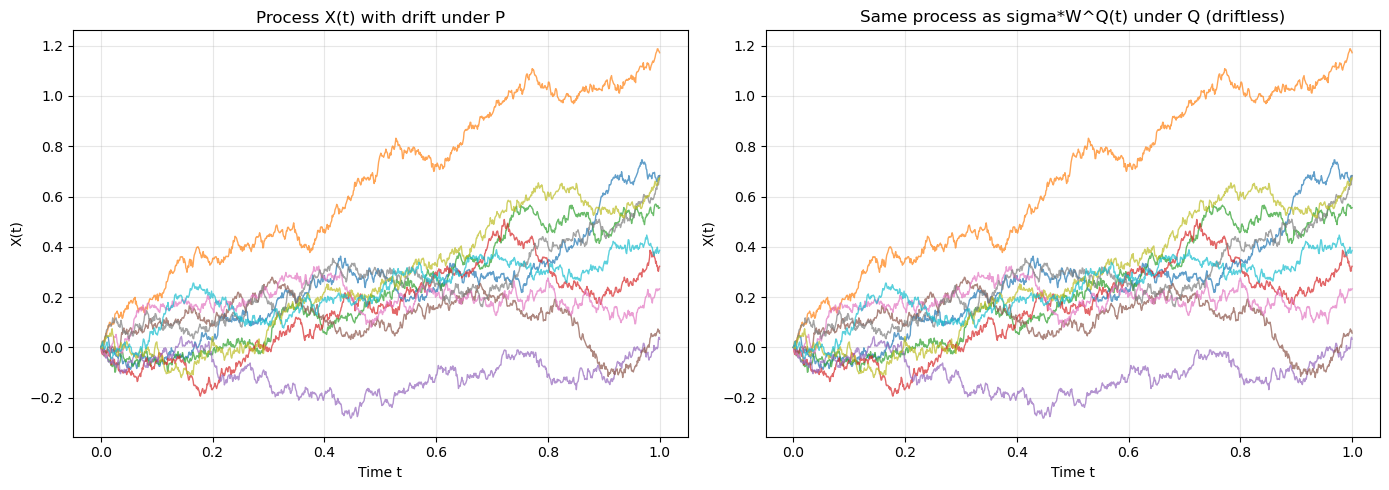

In [5]:
# ============ PLOT 4: Drift Removal Example ============
# Process: dX_t = mu dt + sigma dW_t under P
# Under Q with theta = mu/sigma: dX_t = sigma dW_t^Q (driftless)
mu = 0.5
sigma = 0.3
theta_example = mu / sigma

X = np.zeros((n_paths, N + 1))
for i in range(N):
    X[:, i+1] = X[:, i] + mu * dt + sigma * dW[:, i]

# Under Q: W^Q_t = W_t + theta_example * t
W_Q_example = W + theta_example * t
X_Q = sigma * W_Q_example  # Same paths but driftless representation

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for i in range(n_paths):
    ax.plot(t, X[i], alpha=0.7, linewidth=1)
ax.set_title('Process X(t) with drift under P', fontsize=12)
ax.set_xlabel('Time t')
ax.set_ylabel('X(t)')
ax.grid(True, alpha=0.3)

ax = axes[1]
for i in range(n_paths):
    ax.plot(t, X_Q[i], alpha=0.7, linewidth=1)
ax.set_title('Same process as sigma*W^Q(t) under Q (driftless)', fontsize=12)
ax.set_xlabel('Time t')
ax.set_ylabel('X(t)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Summary

| Concept | Under P | Under Q |
|---------|---------|---------|
| Brownian motion | $W_t$ | $W_t^Q = W_t + \theta t$ |
| Drift of $W$ | 0 | $-\theta$ (in $W$-coordinates) |
| RN derivative | — | $Z_t = \exp(-\theta W_t - \frac{1}{2}\theta^2 t)$ |
| Expectation link | $\mathbb{E}_P[\cdot]$ | $\mathbb{E}_Q[X] = \mathbb{E}_P[Z_T X]$ |

## Why it matters
1. **Option pricing**: Switch to the risk-neutral measure $Q$ where discounted asset prices are martingales.
2. **Importance sampling**: Simulate rare events under $P$ by tilting the measure to $Q$ where they are common, then reweight by $Z_T$.
3. **Filtering and inference**: Change measure to simplify the dynamics of observed processes.

## Generalization (Stochastic $\theta_t$)
For an adapted process $\theta_t$:
$$Z_t = \exp\left(-\int_0^t \theta_s\,dW_s - \frac{1}{2}\int_0^t \theta_s^2\,ds\right)$$
$$W_t^Q = W_t + \int_0^t \theta_s\,ds$$

The constant-$\theta$ case above is just a special case where the integrals simplify.
